In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path

Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    /home/vishwesh/.cache/matplotlib/fontlist-v390.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


In [2]:
df = pd.read_csv("../data/processed_data/bitcoin_final_with_embeddings_lag_7.csv")
df.head()

,Date,Open,High,Low,Close,Adj_Close,Volume,bitcoin_news,summary_gpt-5-mini,summary_gpt-5-mini_lag1,...,Adj_Close_lag5,Adj_Close_lag6,Adj_Close_lag7,embedding_summary_gpt-5-mini_lag1,embedding_summary_gpt-5-mini_lag2,embedding_summary_gpt-5-mini_lag3,embedding_summary_gpt-5-mini_lag4,embedding_summary_gpt-5-mini_lag5,embedding_summary_gpt-5-mini_lag6,embedding_summary_gpt-5-mini_lag7
0,2018-01-01,14112.2,14112.2,13154.7,13657.2,13657.2,1.029120e+10,[{'title': 'Bitcoin vs gold: Safe haven battle...,"Since the beginning of the year, Bitcoin has s...",NaN,...,NaN,NaN,NaN,"[0.018885750323534012, 0.028458246961236, -0.0...","[0.018885750323534012, 0.028458246961236, -0.0...","[0.018885746598243713, 0.028458239510655403, -...","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
1,2018-01-02,13625.0,15444.6,13163.6,14982.1,14982.1,1.684660e+10,[{'title': 'Intel Leaks Details On Desktop Cor...,Intel's overclocking website listing leaked an...,"Since the beginning of the year, Bitcoin has s...",...,NaN,NaN,NaN,"[0.036350738257169724, -0.006545981392264366, ...","[0.018885750323534012, 0.028458246961236, -0.0...","[0.01888575218617916, 0.02845820225775242, -0....","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
2,2018-01-03,14978.2,15572.8,14844.5,15201.0,15201.0,1.687190e+10,[{'title': 'Forks in the Road: 2017 Bitcoin Fo...,"Bitcoin spot price was reported at $15,119 on ...",Intel's overclocking website listing leaked an...,...,NaN,NaN,NaN,"[0.0006876131519675255, 0.0019628999289125204,...","[0.036350738257169724, -0.006545981392264366, ...","[0.01888575218617916, 0.02845820225775242, -0....","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
3,2018-01-04,15270.7,15739.7,14522.2,15599.2,15599.2,2.178320e+10,NaN,NaN,"Bitcoin spot price was reported at $15,119 on ...",...,NaN,NaN,NaN,"[-0.003045563353225589, 0.0033753064926713705,...","[0.0006876131519675255, 0.0019628999289125204,...","[0.036350738257169724, -0.006545981392264366, ...","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
4,2018-01-05,15477.2,17705.2,15202.8,17429.5,17429.5,2.384090e+10,"[{'title': '6 AI techs that will rule 2018', '...","Bitcoin was described in one article as ""feroc...",NaN,...,NaN,NaN,NaN,"[0.018885746598243713, 0.028458239510655403, -...","[-0.003045563353225589, 0.0033753064926713705,...","[0.0006876131519675255, 0.0019628999289125204,...","[0.036350738257169724, -0.006545981392264366, ...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."


In [3]:
df.drop(columns=[f"embedding_summary_gpt-5-mini_lag{i}" for i in range(1, 7 + 1)], inplace=True)

In [4]:
def get_scores(all_vectors, dir1):
    # all_vectors: N x D matrix of N vectors of dimension 4096
    # dir1: D-dimensional vector
    dots = all_vectors @ dir1
    dots_matrix = np.stack([dots, -dots], axis=1)
    exps = np.exp(dots_matrix)
    softmax_scores = exps / np.sum(exps, axis=1, keepdims=True)
    return softmax_scores

def create_lag_matrix(v, d):
    """
    v: Input vector of shape (N,) or (N, 1)
    d: Number of lags to create
    Returns: Matrix of shape (N, d)
    """
    v = v.ravel()
    N = v.shape[0]
    
    # Initialize matrix with NaNs
    lag_matrix = np.full((N, d), np.nan)
    
    for i in range(d):
        # The i-th lag shifts the data down by (i+1)
        lag_val = i + 1
        if lag_val < N:
            # Fill the column from index 'lag_val' to the end
            lag_matrix[lag_val:, i] = v[:-lag_val]
            
    return lag_matrix

In [5]:
#Generate random list of topics for each row in the dataframe
n_topics = 10
list_of_topics = np.random.uniform(0, 1, size=(len(df), n_topics)).tolist()
basis_matrix = np.random.randn(n_topics, 4096)
basis_matrix = basis_matrix / np.linalg.norm(basis_matrix, axis=1, keepdims=True)
topic_embeddings = np.dot(list_of_topics, basis_matrix)
topic_embeddings = topic_embeddings / np.linalg.norm(topic_embeddings, axis=1, keepdims=True)

<Axes: >

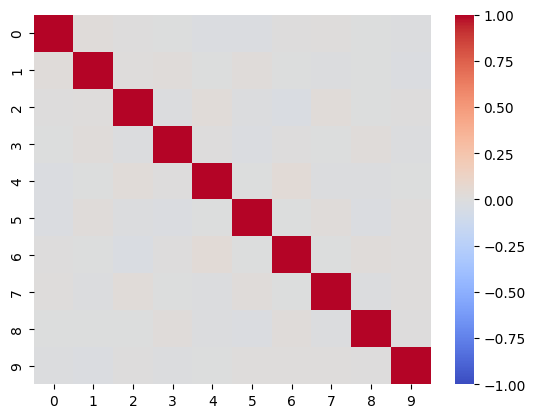

In [6]:
# Geneate cosine similarity scores for each basis vector
cosine_similarity_scores = np.zeros((n_topics,n_topics))
for i in range(n_topics):
    for j in range(i,n_topics):
        cosine_similarity_scores[i,j] = np.dot(basis_matrix[i], basis_matrix[j])/(np.linalg.norm(basis_matrix[i]) * np.linalg.norm(basis_matrix[j]))
        cosine_similarity_scores[j,i] = cosine_similarity_scores[i,j]
# Visualize the cosine similarity scores as a heatmap
sns.heatmap(cosine_similarity_scores, cmap='coolwarm', vmin=-1, vmax=1)

In [7]:
null_vector = np.ravel(np.dot(np.ones((1, n_topics)), basis_matrix))
null_vector = null_vector / np.linalg.norm(null_vector)

In [8]:
import json
dataset_lag = 7
rng = np.random.default_rng(seed=42)
r = rng.standard_normal(len(null_vector))
dir1 = r - (np.dot(r, null_vector) / np.dot(null_vector, null_vector)) * null_vector
dir1 = dir1 / np.linalg.norm(dir1)

topic_embeddings_str = [json.dumps(np.round(topic_embeddings[i],16).tolist()) for i in range(topic_embeddings.shape[0])]

df["embedding_summary_synthetic"] = topic_embeddings_str

# target_lagged_corr = create_lag_matrix(df["embedding_summary_synthetic"].to_numpy(), dataset_lag)
# df = pd.DataFrame(df, columns=[f"embedding_summary_synthetic_lag{i}" for i in range(1, dataset_lag + 1)])

In [9]:
d = 7
v = df["embedding_summary_synthetic"].to_numpy()
v = v.ravel()
N = v.shape[0]

# Initialize matrix with NaNs
lag_matrix = np.full((N, d), json.dumps(null_vector.tolist()))  # Using null_vector as the fill value instead of NaN

for i in range(d):
    # The i-th lag shifts the data down by (i+1)
    lag_val = i + 1
    if lag_val < N:
        # Fill the column from index 'lag_val' to the end
        lag_matrix[lag_val:, i] = v[:-lag_val]

lag_matrix_df = pd.DataFrame(lag_matrix, columns=[f"embedding_summary_synthetic_lag{i}" for i in range(1, dataset_lag + 1)])
df = pd.concat([df, lag_matrix_df], axis=1)

In [10]:
emb_matrix = lag_matrix_df.applymap(lambda x: np.array(x.strip("[]").split(",")).astype(float))

/tmp/ipykernel_1150376/1399088747.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  emb_matrix = lag_matrix_df.applymap(lambda x: np.array(x.strip("[]").split(",")).astype(float))


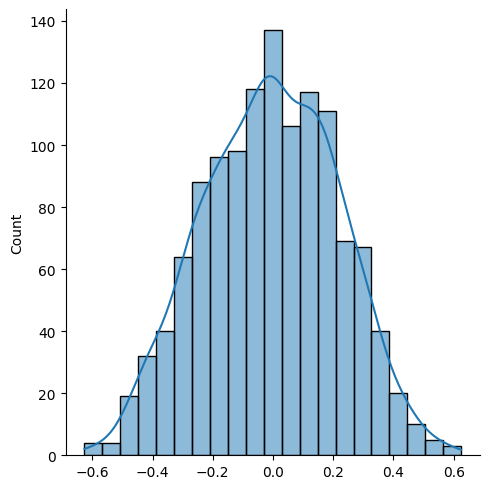

In [11]:
scale = 35
all_scores = get_scores(np.stack(emb_matrix["embedding_summary_synthetic_lag1"].values), dir1)
direction = scale * (all_scores[:, 0] - all_scores[:, 1])
sns.displot(direction,kde=True)

# #Generate lagged features
direction_lags = create_lag_matrix(direction, dataset_lag)
direction_lags[np.where(np.isnan(direction_lags))] = 0.0
direction_lags_df = pd.DataFrame(direction_lags, columns=[f"direction_lag{i}" for i in range(1, dataset_lag + 1)])
df = pd.concat([df, direction_lags_df], axis=1)

In [15]:
df_corr = df.copy()

target_lag = 3
input_cols = ["target", "text_signal"]
init_dict = {"target_lag1": 0.45, "target_lag2": 0.15, "target_lag3": 0.05}

In [16]:
# Create signal from text features
n_points = len(df)
target_mean = 2000
standard_deviation = 0  # Controls how "spread out" the noise is

text_signal = direction * np.random.normal(loc=target_mean, scale=standard_deviation, size=n_points) + 1500

#Generate target variable for additive model
text_signal_lags = create_lag_matrix(text_signal, dataset_lag)
text_signal_lags_df = pd.DataFrame(text_signal_lags, columns=[f"text_signal_lag{i}" for i in range(1, dataset_lag + 1)])
df_corr = pd.concat([df_corr, text_signal_lags_df], axis=1)

/tmp/ipykernel_1150376/709791577.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(text_signal)


<Axes: ylabel='Density'>

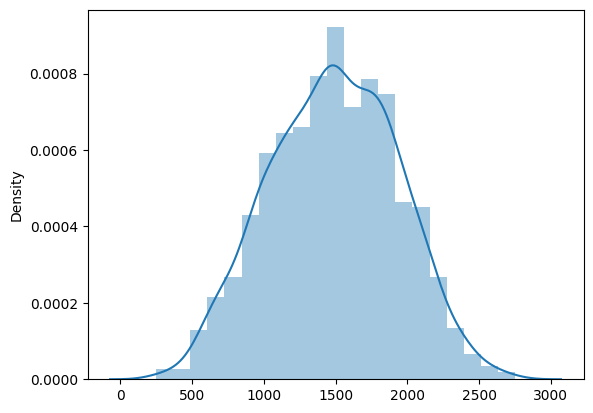

In [17]:
sns.distplot(text_signal)

In [18]:
# trainable_cols_corr = [f"target_lag{j}" for j in range(1, target_lag + 1)]
trainable_cols_corr= [f"text_signal_lag{j}" for j in range(1, target_lag + 1)]

#generate synthetic target variable
noise = rng.standard_normal(len(df))
# random_params = np.random.uniform(0, 1, size=target_lag)
# random_params = random_params / np.linalg.norm(random_params)
param_dict_corr = init_dict.copy()
# param_dict_corr.update({f"text_signal_lag{i}": random_params[i-1] for i in range(1, target_lag + 1)})
param_dict_corr.update({"text_signal_lag1": 0.75, "text_signal_lag2": 0.15, "text_signal_lag3": 0.0})

In [19]:
param_dict_corr

{'target_lag1': 0.45,
 'target_lag2': 0.15,
 'target_lag3': 0.05,
 'text_signal_lag1': 0.75,
 'text_signal_lag2': 0.15,
 'text_signal_lag3': 0.0}

## Target Generation with Correlation

/tmp/ipykernel_1150376/283260300.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_corr["target"].iloc[:target_lag] = additive_text_target
/tmp/ipykernel_1150376/283260300.py:8: SettingWithCopyWarning: 
A value is trying to be set on a 

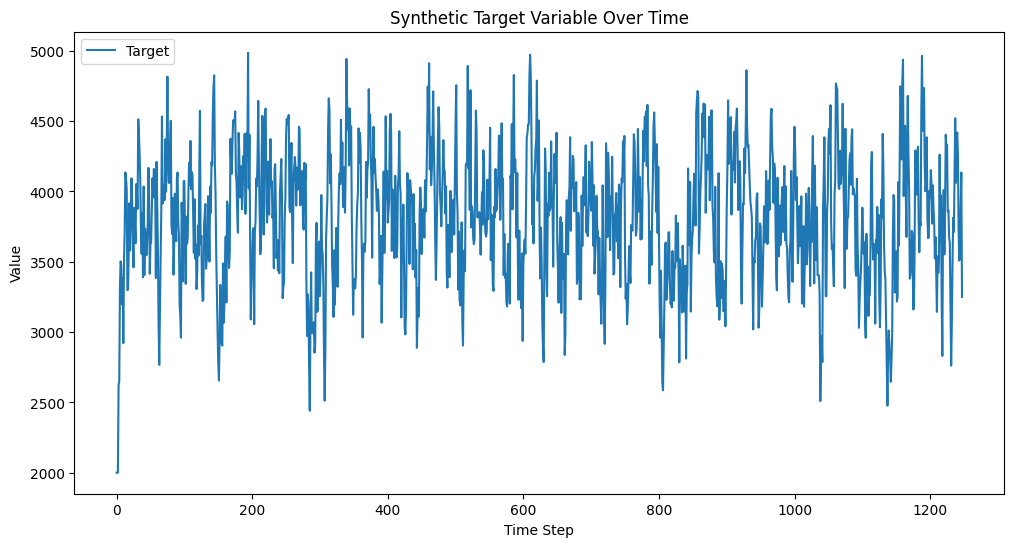

In [20]:
start_val = 2000
end_val = 2000
df_corr["target"] = np.nan

target = list(np.random.uniform(start_val, end_val, size=target_lag)) # Start with random values for the first 'target_lag' entries
additive_text_target = target.copy()

df_corr["target"].iloc[:target_lag] = additive_text_target

for i in range(target_lag, len(df_corr)):
    lagged_values_corr = [additive_text_target[i- j] for j in range(1, target_lag + 1)]
    
    feature_values_corr = df_corr.loc[i, trainable_cols_corr].values

    additive_text_target_value = sum(param_dict_corr[f"target_lag{j}"] * lagged_values_corr[j-1] for j in range(1, target_lag + 1))
    additive_text_target_value += sum(param_dict_corr[trainable_cols_corr[k]] * feature_values_corr[k] for k in range(len(trainable_cols_corr)))
    
    additive_text_target_value += noise[i] * 0 # Add some noise, for now no noise to keep it deterministic

    additive_text_target.append(additive_text_target_value)

df_corr["target"] = additive_text_target

#Plot the target variable and close price to visualize the synthetic data
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(df_corr)), df_corr["target"], label="Target")
# plt.plot(np.arange(len(df_corr)), df_corr["Adj_Close"], label="Adj Close Price")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title("Synthetic Target Variable Over Time")
plt.legend()
plt.show()

In [21]:
#Save the synthetic dataset with lagged features and target variable
target_lagged_corr = create_lag_matrix(df_corr["target"].values, dataset_lag)
target_lags_df = pd.DataFrame(target_lagged_corr, columns=[f"target_lag{i}" for i in range(1, dataset_lag + 1)])
synthetic_df_corr = pd.concat([df_corr, target_lags_df], axis=1)
trainable_cols_corr.extend([f"target_lag{i}" for i in range(1, target_lag + 1)])
synthetic_df_corr.to_csv("../data/processed_data/bitcoin_synthetic_data_corr_textsynth.csv", index=False)

### Baseline

In [22]:
# Train-test split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

clean_df = synthetic_df_corr.iloc[dataset_lag:]
clean_df_additive = synthetic_df_corr.iloc[dataset_lag:]
final_trainable_cols = trainable_cols_corr.copy()
final_trainable_cols_additive = trainable_cols_corr.copy()


train_size = 200
train_df = clean_df.iloc[:train_size]
test_df = clean_df.iloc[train_size:]

### Baseline
print("\nLinear Model: Additive terms from text direction with corr and lags")
linmod = LinearRegression()
linmod.fit(train_df[final_trainable_cols], train_df["target"])
y_train_pred = linmod.predict(train_df[final_trainable_cols])
y_test_pred = linmod.predict(test_df[final_trainable_cols])
print("Train MAE:", mean_absolute_error(train_df["target"], y_train_pred))
print("Train R2:", r2_score(train_df["target"], y_train_pred))
print("Test MAE:", mean_absolute_error(test_df["target"], y_test_pred))
print("Test R2:", r2_score(test_df["target"], y_test_pred))


print("\nLinear Model: Additive terms from text direction, no text signal used (to test if model is actually using text info)")
new_trainable_cols = [col for col in final_trainable_cols if 'text' not in col]
linmod_additive = LinearRegression()
linmod_additive.fit(train_df[new_trainable_cols], train_df["target"])
y_train_pred = linmod_additive.predict(train_df[new_trainable_cols])
y_test_pred = linmod_additive.predict(test_df[new_trainable_cols])
print("Train MAE:", mean_absolute_error(train_df["target"], y_train_pred))
print("Train R2:", r2_score(train_df["target"], y_train_pred))
print("Test MAE:", mean_absolute_error(test_df["target"], y_test_pred))
print("Test R2:", r2_score(test_df["target"], y_test_pred))


Linear Model: Additive terms from text direction with corr and lags
Train MAE: 4.865796654485166e-13
Train R2: 1.0
Test MAE: 4.883838023929557e-13
Test R2: 1.0

Linear Model: Additive terms from text direction, no text signal used (to test if model is actually using text info)
Train MAE: 265.13181103981356
Train R2: 0.4287764488305821
Test MAE: 274.9962027690524
Test R2: 0.4568462841679387


In [ ]:
# linmod_additive = LinearRegression()
# linmod_additive.fit(train_df_additive[final_trainable_cols_additive], train_df_additive["target"])
# y_train_pred = linmod_additive.predict(train_df_additive[final_trainable_cols_additive])
# y_test_pred = linmod_additive.predict(test_df_additive[final_trainable_cols_additive])

# print("Train MAE:", mean_absolute_error(train_df_additive["target"], y_train_pred))
# print("Train R2:", r2_score(train_df_additive["target"], y_train_pred))
# print("Test MAE:", mean_absolute_error(test_df_additive["target"], y_test_pred))
# print("Test R2:", r2_score(test_df_additive["target"], y_test_pred))

Train MAE: 9.19953890843317e-12
Train R2: 1.0
Test MAE: 4.0864903093384996e-11
Test R2: 1.0


In [ ]:
# import pandas as pd
# import numpy as np
# path = "../data/processed_data/bitcoin_synthetic_data_additive.csv"
# target_column = "target"
# target_lag = 3
# numeric_features = [f"Open_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"High_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"Low_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"Close_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"Adj_Close_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"text_signal_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"target_lag{i}" for i in range(1, target_lag + 1)]
# synthetic_df = pd.read_csv(path).iloc[7:,:]
# synthetic_df[target_column] = np.log1p(np.abs(synthetic_df[target_column].values))
# synthetic_df[[col for col in numeric_features if "text_signal" not in col]] = np.log1p(np.abs(synthetic_df[[col for col in numeric_features if "text_signal" not in col]].values))
# synthetic_df[[col for col in numeric_features if "text_signal" in col]] = synthetic_df[[col for col in numeric_features if "text_signal"  in col]].values/6000

# # Train-test split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_absolute_error, r2_score

# train_size = 200
# train_df = synthetic_df.iloc[:train_size]
# test_df = synthetic_df.iloc[train_size:]

# linmod_additive = LinearRegression()
# linmod_additive.fit(train_df[numeric_features], train_df["target"])
# y_train_pred = linmod_additive.predict(train_df[numeric_features])
# y_test_pred = linmod_additive.predict(test_df[numeric_features])

# print("Train MAE:", mean_absolute_error(train_df["target"], y_train_pred))
# print("Train R2:", r2_score(train_df["target"], y_train_pred))
# print("Test MAE:", mean_absolute_error(test_df["target"], y_test_pred))
# print("Test R2:", r2_score(test_df["target"], y_test_pred))

Train MAE: 1.007265382213518e-11
Train R2: 1.0
Test MAE: 4.5041065124580575e-11
Test R2: 1.0


In [2]:
df = pd.read_csv("../data/processed_data/bitcoin_synthetic_data_corr_textsimple.csv")
df_corr = df[["text_signal_lag1", "text_signal_lag2", "text_signal_lag3", "target_signal_lag1", "target_signal_lag2", "target_signal_lag3", "target"]]

KeyError: "['target_signal_lag1', 'target_signal_lag2', 'target_signal_lag3'] not in index"